# Customer Segmentation and RFM Analysis

## Objective

Generate RFM-based customer features to understand purchasing behavior and prepare the dataset for customer segmentation analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_excel("../data/online_retail_II.xlsx")

df = df.dropna(subset=["Customer ID"])

df["TotalAmount"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1) #Snapshot Date

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2010-12-10 20:01:00


# RFM Calculation

In [4]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "TotalAmount": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


In [5]:
#RFM Summary
rfm.describe()

,Recency,Frequency,Monetary
count,4383.000000,4383.000000,4383.000000
mean,91.395163,5.381474,1904.679118
std,98.176493,10.051921,8519.369281
min,1.000000,1.000000,-25111.090000
25%,17.000000,1.000000,285.260000
50%,52.000000,3.000000,655.940000
75%,138.000000,6.000000,1645.690000
max,374.000000,270.000000,341776.730000


# RFM Scores

In [6]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

# Final RFM Score

In [7]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
12346.0,67,15,-64.68,3,5,1,351
12347.0,3,2,1323.32,5,2,4,524
12348.0,74,1,222.16,2,1,1,211
12349.0,43,4,2646.99,3,3,5,335
12351.0,11,1,300.93,5,1,2,512


# Top Customers

In [8]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer ID,,,,,,,
18102.0,1,95,341776.73,5,5,5,555
14646.0,10,87,243853.05,5,5,5,555
14156.0,7,138,183180.55,5,5,5,555
14911.0,1,270,137675.91,5,5,5,555
13694.0,9,105,128172.42,5,5,5,555
17511.0,3,42,83760.60,5,5,5,555
15061.0,3,90,82162.74,5,5,5,555
16684.0,15,34,75610.17,5,5,5,555
13089.0,4,132,55828.31,5,5,5,555


# Purchase Frequency

In [9]:
purchase_frequency = (
    df["Invoice"].nunique()
    /
    df["Customer ID"].nunique()
)

print("Purchase Frequency:", round(purchase_frequency,2))

Purchase Frequency: 5.38


# Basket Size

In [10]:
basket_size = (
    df.groupby("Invoice")["Quantity"]
      .sum()
      .mean()
)

print("Average Basket Size:", round(basket_size,2))

Average Basket Size: 225.85


# Simple Customer Lifetime Value


In [11]:
average_order_value = (
    df.groupby("Invoice")["TotalAmount"]
      .sum()
      .mean()
)

customer_lifetime_value = (
    average_order_value
    *
    purchase_frequency
)

print("Average Order Value:", round(average_order_value,2))

print("Estimated CLV:", round(customer_lifetime_value,2))

Average Order Value: 353.93
Estimated CLV: 1904.68


# Recency Distribution

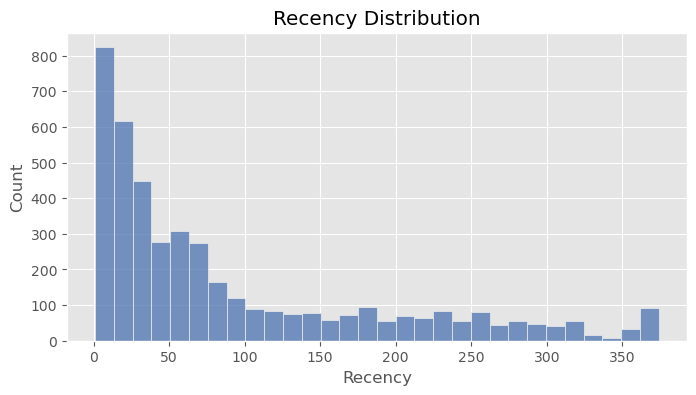

In [12]:
plt.figure(figsize=(8,4))

sns.histplot(
    rfm["Recency"],
    bins=30,
    color="#4C72B0"
)

plt.title("Recency Distribution")

plt.show()

# Frequency Distribution

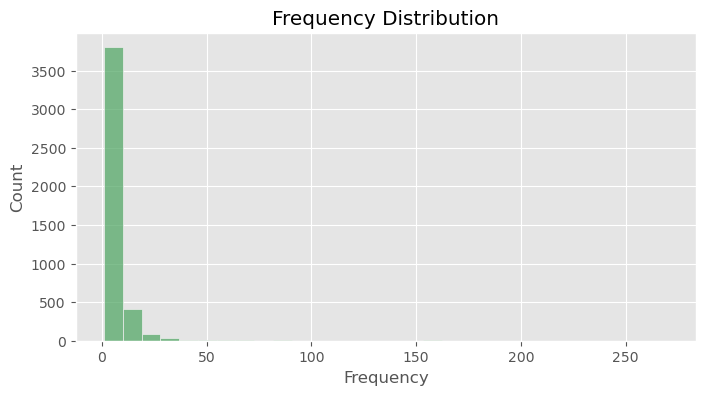

In [13]:
plt.figure(figsize=(8,4))

sns.histplot(
    rfm["Frequency"],
    bins=30,
    color="#55A868"
)

plt.title("Frequency Distribution")

plt.xlabel("Frequency")

plt.ylabel("Count")

plt.show()

# Monetary Distribution

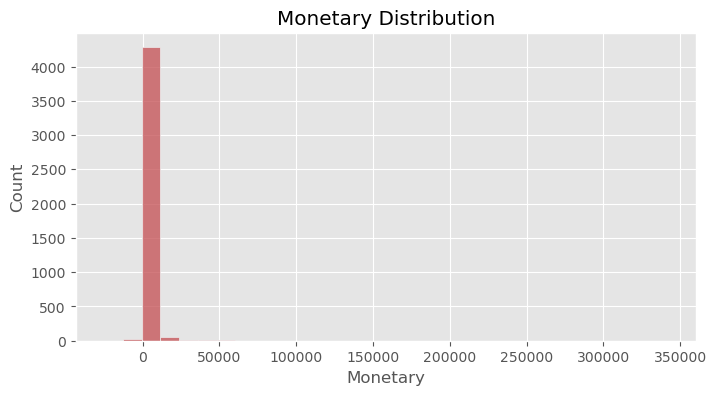

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(
    rfm["Monetary"],
    bins=30,
    color="#C44E52"
)

plt.title("Monetary Distribution")

plt.xlabel("Monetary")

plt.ylabel("Count")

plt.show()

# Top 10 Customers by Revenue

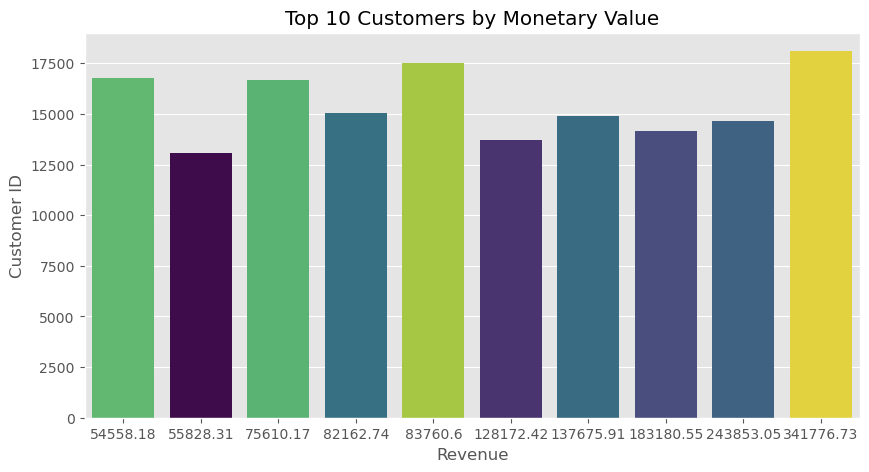

In [15]:
top_customers = rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_customers["Monetary"],
    y=top_customers.index,
    hue=top_customers.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Customers by Monetary Value")

plt.xlabel("Revenue")

plt.ylabel("Customer ID")

plt.show()

## Findings

- Customer purchase frequency varies significantly across the customer base.

- A small number of customers contribute a disproportionately large share of total revenue.

- Monetary values show a highly skewed distribution, indicating the presence of high-value customers.

- Recency analysis highlights both active and inactive customer groups.

- RFM scores provide a structured framework for identifying valuable customer segments.

## Conclusion

Customer-level features including Recency, Frequency and Monetary value were successfully generated.

The resulting RFM dataset provides a foundation for customer segmentation and will be used in the next phase to identify distinct customer groups using clustering techniques.

## Objective

Segment customers based on RFM metrics using K-Means clustering to identify distinct purchasing behavior patterns and support targeted business strategies.

# Feature Selection

In [16]:
rfm_features = rfm[["Recency","Frequency","Monetary"]]

rfm_features.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,67,15,-64.68
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,4,2646.99
12351.0,11,1,300.93


# Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[-0.24851108,  0.95699354, -0.23118892],
       [-0.90047267, -0.33643914, -0.06824748],
       [-0.17720278, -0.43593396, -0.19751592],
       [-0.49299668, -0.1374495 ,  0.08714208],
       [-0.81897747, -0.43593396, -0.18826888]])

# Elbow Method

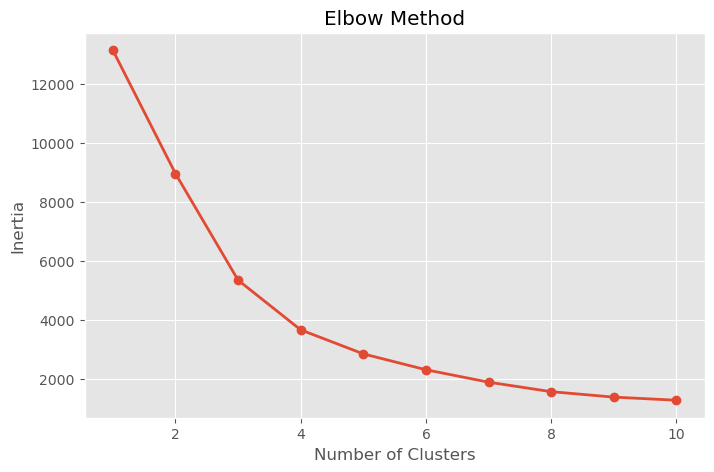

In [18]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o",
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

# Silhouette Analysis

In [19]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(f"K={k}  Silhouette Score={score:.3f}")

K=2  Silhouette Score=0.916
K=3  Silhouette Score=0.590
K=4  Silhouette Score=0.609
K=5  Silhouette Score=0.605
K=6  Silhouette Score=0.527
K=7  Silhouette Score=0.505
K=8  Silhouette Score=0.499
K=9  Silhouette Score=0.403
K=10  Silhouette Score=0.410


# Final Model

In [20]:
kmeans = KMeans( # kmeans
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster
Customer ID,,,,,,,,
12346.0,67,15,-64.68,3,5,1,351,0
12347.0,3,2,1323.32,5,2,4,524,0
12348.0,74,1,222.16,2,1,1,211,0
12349.0,43,4,2646.99,3,3,5,335,0
12351.0,11,1,300.93,5,1,2,512,0


# Cluster Size

In [21]:
rfm["Cluster"].value_counts()

Cluster
0    3248
2    1076
3      54
1       5
Name: count, dtype: int64

# Segment Summary

In [22]:
segment_summary = rfm.groupby(
    "Cluster"
)[["Recency","Frequency","Monetary"]].mean()

segment_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.164717,5.426108,1658.667487
1,5.600000,139.000000,206931.732000
2,244.463755,1.904275,407.532708
3,10.425926,59.611111,27549.865241


## Segment Naming

In [23]:
segment_names = { #segment names
    0: "Regular Customers",
    1: "High Value Customers",
    2: "At Risk Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Cluster,Segment
Customer ID,,,,,,,,,
12346.0,67,15,-64.68,3,5,1,351,0,Regular Customers
12347.0,3,2,1323.32,5,2,4,524,0,Regular Customers
12348.0,74,1,222.16,2,1,1,211,0,Regular Customers
12349.0,43,4,2646.99,3,3,5,335,0,Regular Customers
12351.0,11,1,300.93,5,1,2,512,0,Regular Customers


In [24]:
print(rfm["Segment"].unique())

['Regular Customers' 'At Risk Customers' 'Loyal Customers'
 'High Value Customers']


# Visualization

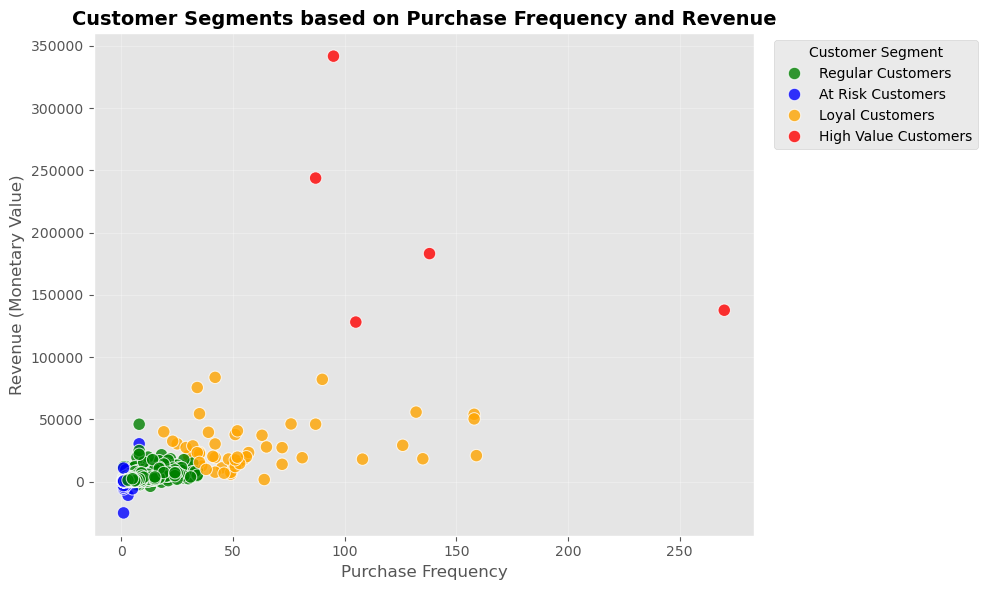

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette={
        "High Value Customers":"red",
        "Loyal Customers":"orange",
        "Regular Customers":"green",
        "At Risk Customers":"blue"
    },
    s=80,
    alpha=0.8
)

plt.title(
    "Customer Segments based on Purchase Frequency and Revenue",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Purchase Frequency", fontsize=12)
plt.ylabel("Revenue (Monetary Value)", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


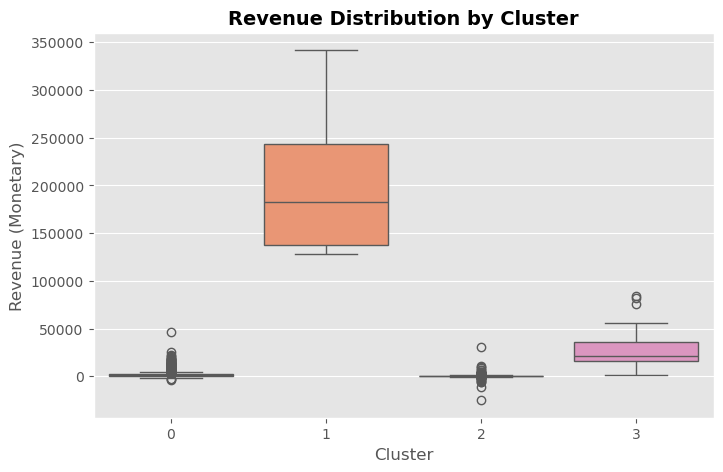

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=rfm,
    x="Cluster",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    legend=False
)

plt.title("Revenue Distribution by Cluster", fontsize=14, fontweight="bold")
plt.xlabel("Cluster")
plt.ylabel("Revenue (Monetary)")
plt.show()

# Customer Segment Profiling and Business Insights

## Segment Profiling

In [28]:
segment_profile = rfm.groupby("Segment").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

segment_profile

,Recency,Frequency,Monetary
Segment,,,
At Risk Customers,244.46,1.90,407.53
High Value Customers,5.60,139.00,206931.73
Loyal Customers,10.43,59.61,27549.87
Regular Customers,42.16,5.43,1658.67


## Segment Characteristics Visualization

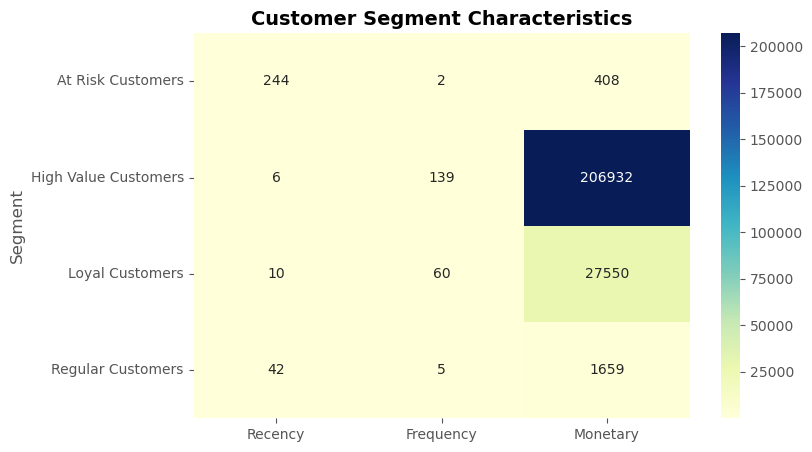

In [29]:
plt.figure(figsize=(8,5))

sns.heatmap(
    segment_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title(
    "Customer Segment Characteristics",
    fontsize=14,
    fontweight="bold"
)

plt.show()

## Segment Comparison Analysis

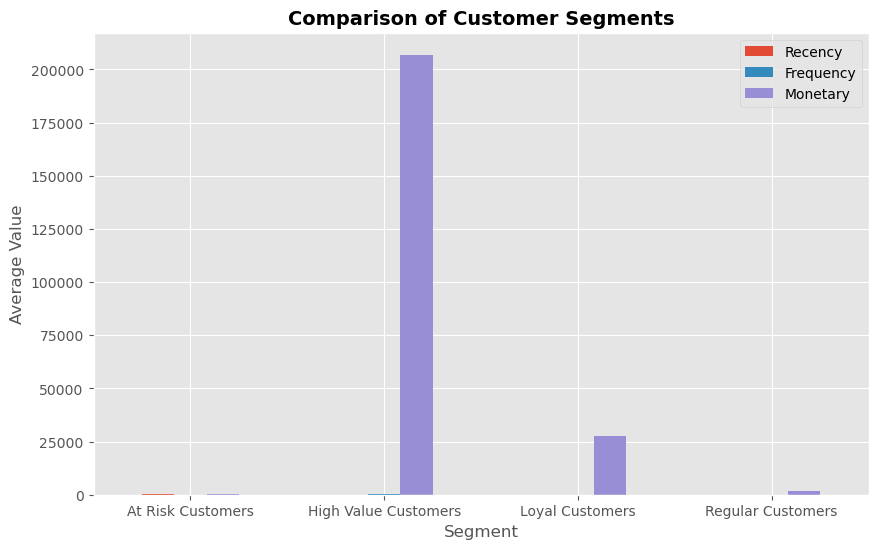

In [30]:
segment_profile.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Comparison of Customer Segments",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

## Business Recommendations

### High Value Customers
Highest revenue-generating segment. Retention should be prioritized to protect overall business revenue.

### Loyal Customers
Strong purchase frequency and consistent spending behavior. This segment has the potential to move into the High Value category.

### Regular Customers
Moderate purchasing activity. Increasing purchase frequency could significantly improve revenue contribution.

### At Risk Customers
Lowest engagement levels and highest recency values. Immediate reactivation efforts may help reduce customer churn.

# Findings

- K-Means clustering identified 4 distinct customer segments.
- High Value Customers generated the highest revenue and purchase frequency.
- Loyal Customers showed strong engagement and consistent purchasing behavior.
- Regular Customers represented the largest customer base with moderate spending.
- At Risk Customers exhibited low engagement and higher churn risk.
- Segment-specific marketing strategies can improve retention and revenue.

# Conclusion

Customer segmentation was successfully performed using RFM metrics and K-Means clustering.

Four distinct customer segments were identified based on purchasing behavior. High Value Customers contribute the largest share of revenue, while At Risk Customers require targeted retention efforts. Loyal and Regular Customers provide opportunities for growth through personalized marketing and cross-selling strategies.

These insights can support customer retention, revenue optimization, and data-driven business decision-making.